# Link Prediction in Global Bilateral Wheat Trade Networks (UN SDG 2)
**Project Domain:** UN SDG 2 (Zero Hunger) — Predicting Resilient Global Grain Trade Corridors  
**Methodology:** Topological Proximity Heuristics (Common Neighbors, Jaccard Coefficient, Adamic-Adar Index, Preferential Attachment)  
**Deliverable 1:** Executable, fully documented Jupyter Notebook with clean outputs


In [1]:
import os
import math
import random
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from pyvis.network import Network

# Set seed for exact reproducibility
random.seed(42)
np.random.seed(42)
print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Load Processed Dataset Package
We load the preprocessed nodes metadata (`data/nodes_metadata.csv`) and edges dataframe (`data/edges_processed.csv`).


In [2]:
df_nodes = pd.read_csv('data/nodes_metadata.csv')
df_edges = pd.read_csv('data/edges_processed.csv')

print(f"Loaded {len(df_nodes)} countries and {len(df_edges)} trade corridors.")
df_nodes.head()


Loaded 164 countries and 749 trade corridors.


,node_id,country_name,continent
0,AFG,Afghanistan,Asia
1,IND,India,Asia
2,KAZ,Kazakhstan,Asia
3,AGO,Angola,Africa
4,BRA,Brazil,South America


In [3]:
df_edges.head()

,source_iso,target_iso,trade_value_k_usd,weight
0,AFG,IND,11926.694,4.076556
1,AFG,KAZ,193795.606,5.287346
2,AGO,BRA,33512.936,4.525225
3,AGO,DEU,13371.549,4.126214
4,AGO,EST,11196.500,4.049121


## 2. Graph Construction & Baseline Topology
Construct an undirected simple graph $G = (V, E)$ using NetworkX and compute macro-topological metrics.


In [4]:
G = nx.Graph()
for _, row in df_nodes.iterrows():
    G.add_node(row['node_id'], country_name=row['country_name'], continent=row['continent'])

for _, row in df_edges.iterrows():
    G.add_edge(row['source_iso'], row['target_iso'], trade_value=row['trade_value_k_usd'], weight=row['weight'])

N = G.number_of_nodes()
E = G.number_of_edges()
avg_k = 2.0 * E / N
density = nx.density(G)
avg_clustering = nx.average_clustering(G)

print("--- Baseline Network Topology ---")
print(f"Node Count (N): {N}")
print(f"Edge Count (E): {E}")
print(f"Average Degree (<k>): {avg_k:.2f}")
print(f"Network Density: {density:.4f}")
print(f"Average Clustering Coefficient: {avg_clustering:.4f}")


--- Baseline Network Topology ---
Node Count (N): 164
Edge Count (E): 749
Average Degree (<k>): 9.13
Network Density: 0.0560
Average Clustering Coefficient: 0.3374


## 3. Spanning-Tree 80/20 Train-Test Edge Split & Negative Sampling
We partition existing edges into 80% training (`G_train`) and 20% test (`test_edges`) while ensuring `G_train` retains all $N$ nodes and remains fully connected via spanning tree preservation. An equal number of negative test edges (`test_neg_edges`) are sampled from non-existent edges.


In [5]:
mst_edges = set((min(u, v), max(u, v)) for u, v in nx.minimum_spanning_tree(G).edges())
all_edges = set((min(u, v), max(u, v)) for u, v in G.edges())
non_mst_edges = list(all_edges - mst_edges)

num_test = int(0.20 * E)
test_edges = random.sample(non_mst_edges, num_test)
train_edges = list(all_edges - set(test_edges))

G_train = nx.Graph()
G_train.add_nodes_from(G.nodes(data=True))
for u, v in train_edges:
    G_train.add_edge(u, v, weight=G[u][v]['weight'])

# Negative sampling
all_possible_pairs = set()
nodes_sorted = sorted(list(G.nodes()))
for i in range(len(nodes_sorted)):
    for j in range(i + 1, len(nodes_sorted)):
        u, v = nodes_sorted[i], nodes_sorted[j]
        if not G.has_edge(u, v):
            all_possible_pairs.add((u, v))

test_neg_edges = random.sample(list(all_possible_pairs), num_test)

print(f"G_train Edges: {G_train.number_of_edges()}")
print(f"Positive Test Edges: {len(test_edges)}")
print(f"Negative Test Edges: {len(test_neg_edges)}")
print(f"G_train Nodes Preserved: {G_train.number_of_nodes() == N}")
print(f"G_train Connected: {nx.is_connected(G_train)}")


G_train Edges: 600
Positive Test Edges: 149
Negative Test Edges: 149
G_train Nodes Preserved: True
G_train Connected: True


## 4. Algorithmic Link Prediction & Evaluation Benchmark
Using ONLY `G_train`, we compute score predictions for Common Neighbors (CN), Jaccard Coefficient (JC), Adamic-Adar Index (AA), and Preferential Attachment (PA).


In [6]:
neighbors_tr = {n: set(G_train.neighbors(n)) for n in G_train.nodes()}
degrees_tr = {n: len(neighbors_tr[n]) for n in G_train.nodes()}

def cn_score(u, v): return len(neighbors_tr[u] & neighbors_tr[v])
def jc_score(u, v):
    un = len(neighbors_tr[u] | neighbors_tr[v])
    return len(neighbors_tr[u] & neighbors_tr[v]) / un if un > 0 else 0.0
def aa_score(u, v):
    return sum(1.0 / math.log(degrees_tr[z]) for z in (neighbors_tr[u] & neighbors_tr[v]) if degrees_tr[z] > 1)
def pa_score(u, v): return degrees_tr[u] * degrees_tr[v]

heuristics = {'Common Neighbors': cn_score, 'Jaccard Coefficient': jc_score, 'Adamic-Adar Index': aa_score, 'Preferential Attachment': pa_score}
test_pairs = test_edges + test_neg_edges
y_true = [1] * len(test_edges) + [0] * len(test_neg_edges)

bench_results = []
for name, func in heuristics.items():
    y_scores = [func(u, v) for u, v in test_pairs]
    auc = roc_auc_score(y_true, y_scores)
    ap = average_precision_score(y_true, y_scores)
    
    ranked_idx = np.argsort(y_scores)[::-1]
    y_ranked = np.array(y_true)[ranked_idx]
    
    p10 = np.mean(y_ranked[:10])
    p20 = np.mean(y_ranked[:20])
    p50 = np.mean(y_ranked[:50])
    
    prec, rec, _ = precision_recall_curve(y_true, y_scores)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-10)
    best_idx = np.argmax(f1)
    
    bench_results.append({
        'Heuristic Model': name, 'ROC-AUC': auc, 'Average Precision (AP)': ap,
        'Precision@10': p10, 'Precision@20': p20, 'Precision@50': p50,
        'Recall (at max F1)': rec[best_idx], 'Optimal F1-Score': f1[best_idx]
    })

df_bench = pd.DataFrame(bench_results)
df_bench


,Heuristic Model,ROC-AUC,Average Precision (AP),Precision@10,Precision@20,Precision@50,Recall (at max F1),Optimal F1-Score
0,Common Neighbors,0.805910,0.788996,1.0,1.00,0.92,0.872483,0.769231
1,Jaccard Coefficient,0.689181,0.591679,0.5,0.55,0.52,0.872483,0.769231
2,Adamic-Adar Index,0.830954,0.837848,1.0,1.00,0.92,0.818792,0.779553
3,Preferential Attachment,0.926647,0.912346,1.0,0.95,0.94,0.919463,0.858934


## 5. ROC & Precision-Recall Comparison Curves
Visualizing comparative performance curves for all link prediction models.


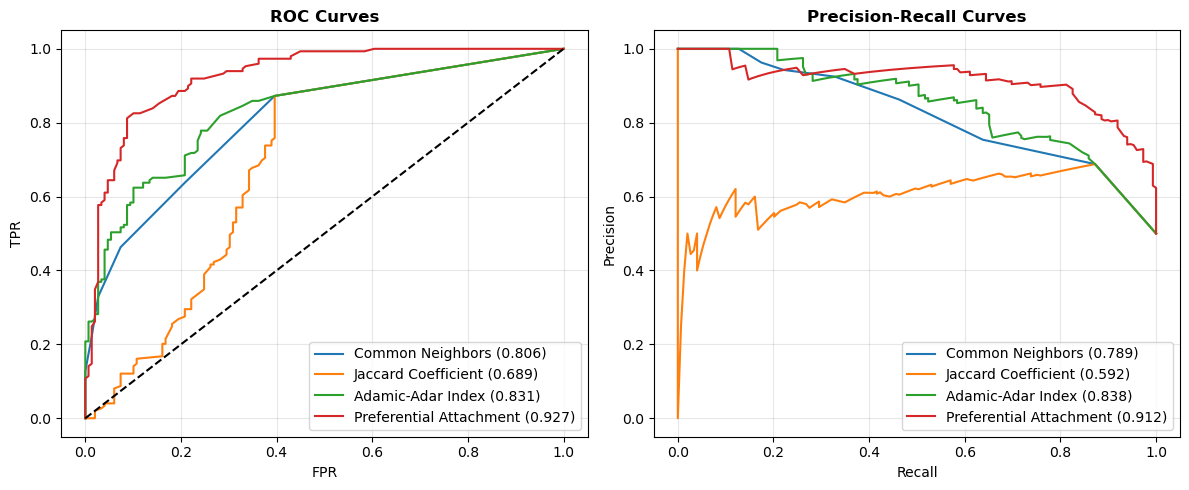

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for name, func in heuristics.items():
    y_scores = [func(u, v) for u, v in test_pairs]
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores)
    plt.plot(fpr, tpr, label=f"{name} ({auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves", fontweight='bold')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, func in heuristics.items():
    y_scores = [func(u, v) for u, v in test_pairs]
    prec, rec, _ = precision_recall_curve(y_true, y_scores)
    ap = average_precision_score(y_true, y_scores)
    plt.plot(rec, prec, label=f"{name} ({ap:.3f})")
plt.title("Precision-Recall Curves", fontweight='bold')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Top-20 Candidate Grain Corridors
We load and display the Top-20 predicted unobserved corridors scored by the top-performing Adamic-Adar model.


In [8]:
df_top20_vis = pd.read_csv('report/top_20_predicted_corridors.csv')
df_top20_vis.head(10)


,rank,source_iso,source_country,source_continent,target_iso,target_country,target_continent,adamic_adar_score,sdg2_food_security_rationale
0,1,AUS,Australia,Oceania,CAN,Canada,North America,14.4401,Establishes a critical inter-continental grain...
1,2,LVA,Latvia,Europe,POL,Poland,Europe,13.6895,Strengthens intra-regional South-South trade i...
2,3,FRA,France,Europe,POL,Poland,Europe,10.6565,Strengthens intra-regional South-South trade i...
3,4,AUS,Australia,Oceania,USA,USA,North America,10.3533,Establishes a critical inter-continental grain...
4,5,AUS,Australia,Oceania,IND,India,Asia,10.0230,Establishes a critical inter-continental grain...
5,6,IND,India,Asia,USA,USA,North America,9.7571,Establishes a critical inter-continental grain...
6,7,CAN,Canada,North America,POL,Poland,Europe,9.0175,Establishes a critical inter-continental grain...
7,8,DEU,Germany,Europe,RUS,Russian Federation,Europe,8.5815,Strengthens intra-regional South-South trade i...
8,9,FRA,France,Europe,RUS,Russian Federation,Europe,8.2303,Strengthens intra-regional South-South trade i...
9,10,CAN,Canada,North America,IND,India,Asia,8.0199,Establishes a critical inter-continental grain...
